# Pipeline klasyfikacji obrazów

Zbiór to zdjęcia śmieci z przypisanymi etykietami:
- cardboard
- glass
- metal
- paper
- plastic
- trash

## Preprocessing
Za nim co kolwiek zrobimy z danymi, powinniśmy na nie spojrzeć.

In [1]:
import pandas as pd
import sklearn
import keras
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
raw_df = pd.read_csv('./train/_classes.csv')
raw_df.head()

,filename,cardboard,glass,metal,paper,plastic,trash
0,paper59_jpg.rf.wzR5NbRz2yDZECnFaw2m.jpg,0,0,0,1,0,0
1,plastic34_jpg.rf.wzyVtvyXtoYA45vl2U7m.jpg,0,0,0,0,1,0
2,glass131_jpg.rf.xKSWDJgXD3JxEOJrObp4.jpg,0,1,0,0,0,0
3,metal155_jpg.rf.xZPyMvYIV6SuhJdqYibK.jpg,0,0,1,0,0,0
4,metal53_jpg.rf.xvclQIoWptlLu6TuixHa.jpg,0,0,1,0,0,0


2524
filename     0
cardboard    0
glass        0
metal        0
paper        0
plastic      0
trash        0
dtype: int64


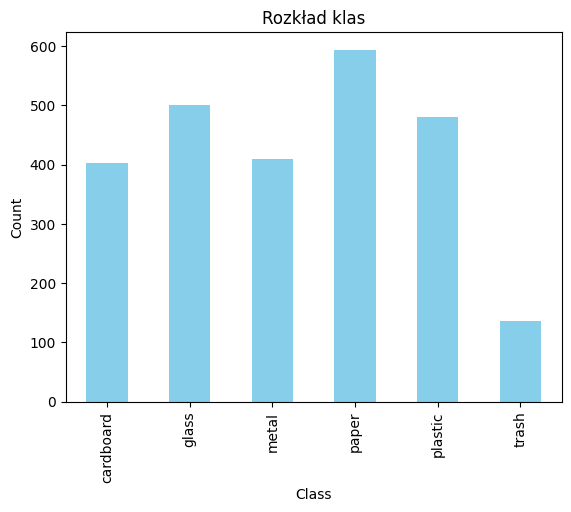

In [3]:
class_counts = raw_df.drop('filename', axis=1).sum()
print(class_counts.sum())
print(raw_df.isnull().sum()) 
class_counts.plot(kind='bar', color='skyblue', )
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Rozkład klas')
plt.show()

Nie ma pustych wartości, liczba klas jest równa liczbie zdjęć, więc nie ma sytuacji gdzie zdjęcie nie ma przypisanej klasy lub jest przypisane do kilku klas


In [ ]:
import tensorflow as tf

class_names = raw_df.columns[1:]

file_names = raw_df['filename'].values
labels = raw_df[class_names].values
labels

dataset = tf.data.Dataset.from_tensor_slices((file_names, labels))

def load_img(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [224,224])
    img = img / 255.0
    return img, label

dataset = dataset.map(load_img).shuffle(1000).batch(32).prefetch(tf.data.AUTOTUNE)
dataset

from tensorflow.keras import layers, models


<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 6), dtype=tf.int64, name=None))>